In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, roc_curve
)

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("Ready!")

Ready!


In [2]:
df = pd.read_csv('emails.csv')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'<[^>]+>', ' ', text)
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess_text)
X = df['clean_text']
y = df['spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 4582 | Test: 1146


In [3]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

nb = MultinomialNB(alpha=0.1)
nb.fit(X_train_tfidf, y_train)

svm = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=3000, random_state=42), cv=3)
svm.fit(X_train_tfidf, y_train)

print("Both models trained!")

Both models trained!


In [4]:
def get_metrics(model, X_test_vec, y_test, name):
    y_pred = model.predict(X_test_vec)
    y_prob = model.predict_proba(X_test_vec)[:, 1]
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'F1'       : round(f1_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 4),
    }, y_pred, y_prob

nb_metrics,  nb_pred,  nb_prob  = get_metrics(nb,  X_test_tfidf, y_test, 'Naive Bayes')
svm_metrics, svm_pred, svm_prob = get_metrics(svm, X_test_tfidf, y_test, 'SVM')

# LSTM values from teammate's LSTM.ipynb
lstm_metrics = {
    'Model': 'LSTM', 'Accuracy': 0.990, 'F1': 0.990,
    'Precision': 0.991, 'Recall': 0.989, 'ROC-AUC': 0.997
}

results = pd.DataFrame([nb_metrics, svm_metrics, lstm_metrics]).set_index('Model')
print(results)

             Accuracy      F1  Precision  Recall  ROC-AUC
Model                                                    
Naive Bayes    0.9869  0.9724     0.9814  0.9635   0.9993
SVM            0.9939  0.9872     0.9855  0.9891   0.9996
LSTM           0.9900  0.9900     0.9910  0.9890   0.9970


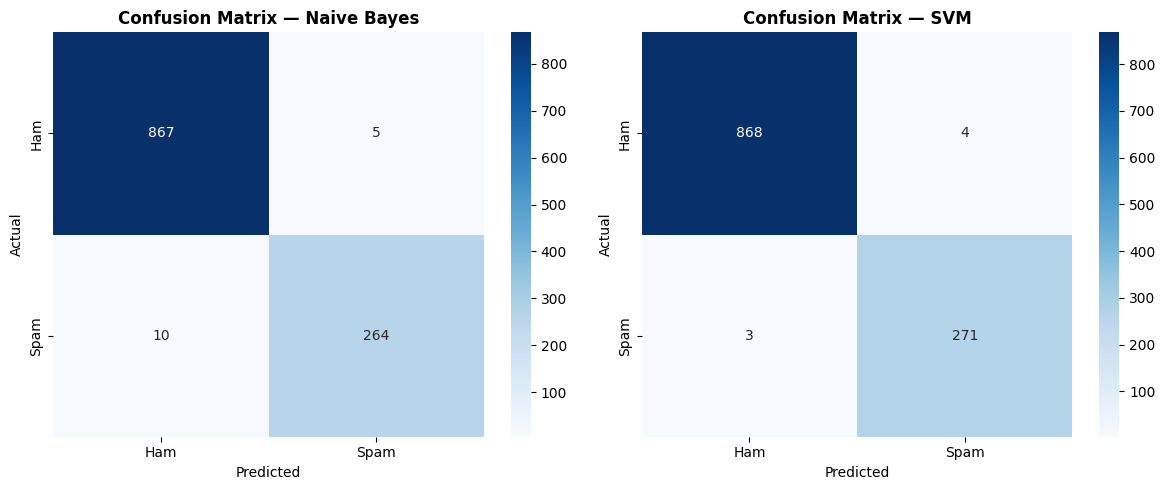

Saved: confusion_matrices.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, pred) in zip(axes, [('Naive Bayes', nb_pred), ('SVM', svm_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print("Saved: confusion_matrices.png")

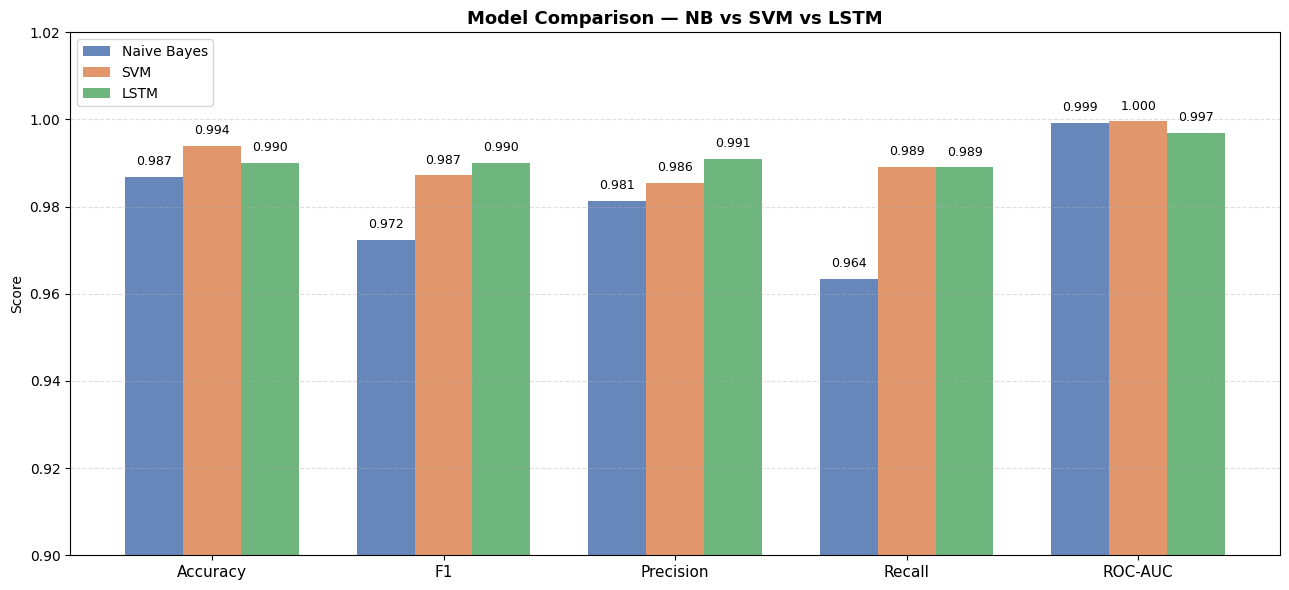

Saved: model_comparison.png


In [6]:
metrics_cols = ['Accuracy', 'F1', 'Precision', 'Recall', 'ROC-AUC']
x     = np.arange(len(metrics_cols))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (model_name, color) in enumerate(zip(results.index, colors)):
    vals = results.loc[model_name, metrics_cols].values.astype(float)
    bars = ax.bar(x + i*width, vals, width, label=model_name, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_cols, fontsize=11)
ax.set_ylim(0.90, 1.02)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — NB vs SVM vs LSTM', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Saved: model_comparison.png")

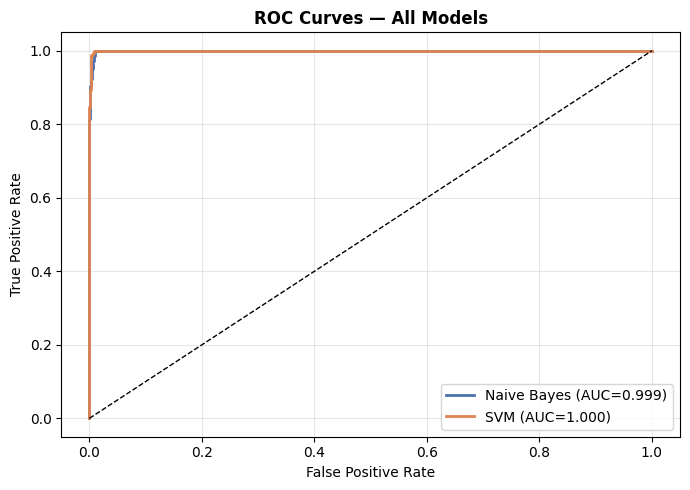

Saved: roc_curves.png


In [7]:
plt.figure(figsize=(7, 5))

for name, prob, color in [('Naive Bayes', nb_prob, '#4C72B0'), ('SVM', svm_prob, '#DD8452')]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()
print("Saved: roc_curves.png")